In [1]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
import pandas as pd
from ligo.segments import segment, segmentlist, segmentlistdict
from pycbc.dq import query_str
import wget, json, itertools

In [4]:
import pycbc.workflow as wf
import itertools
import gwpy
colors = {"L1":"gwpy:ligo-livingston", "H1":"gwpy:ligo-hanford", "V1":"gwpy:virgo"}

In [5]:
ifos = ["H1", "L1", "V1"]
gps_start = 1256655618 #o3b
# gps_start = 1126051217 #o1
gps_end = 1269363618 #o3b
observing_runs = segmentlistdict()
observing_runs["O3b"] = segmentlist([(1256655618, 1269363618)]).coalesce()
observing_runs["O3a"] = segmentlist([(1253977218, 1238166018)]).coalesce()
observing_runs["O2"] = segmentlist([(1164556817, 1187733618)]).coalesce()
observing_runs["O1"] = segmentlist([(1126051217, 1137254417)]).coalesce()
run_durations = dict(abs(observing_runs))

In [6]:
run_durations

{'O3b': 12708000, 'O3a': 15811200, 'O2': 23176801, 'O1': 11203200}

In [7]:
# query_str("H1", f"+H1:DATA:1<-8:8>[{gps_start}:{gps_end}]", gps_start, gps_end, source="GWOSC")

# Load segments directly
Segment files downloaded from here: https://www.gw-openscience.org/timeline/show/history/

and here https://www.gw-openscience.org/archive/

_segments files equivalent to CAT1 for O3b (and probs others -- but should check)

In [8]:
# urlbase = "https://www.gw-openscience.org/timeline/segments/json/O3b_16KHZ_R1/{}_CBC_CAT{}/1256655618/12708000/"
# for ifo in ifos:
#     for cat in ["1", "2", "3"]:
#         wget.download(urlbase.format(ifo, cat), out=f"segments/{ifo}_CAT{cat}.json")

100% [..........................................................] 57334 / 57334

In [9]:
# Generator for producing ifo combinations
def ifo_combos(ifos, min_ifos=2):
    for i in range(min_ifos, len(ifos)+1):
        combinations = itertools.combinations(ifos, i)
        for ifocomb in combinations:
            if len(ifocomb)==1:
                ifocomb = ifocomb[0]
            yield ifocomb
def open_file(ifos):
    fname = "segments/{}_segments.json"
    for ifo in ifos:
        yield ifo, open(fname.format(ifo), "r")
segments = segmentlistdict()
for run, s in observing_runs.items():
    segments[run] = s
segments["advanced"] = segments.union(observing_runs.keys())

for ifo, f in open_file(ifos):
    segments[ifo] = segmentlist(json.load(f)["segments"]).coalesce()
    # remove S6 and earlier
    segments[ifo] = segments.intersection(["advanced", ifo])

for ifocomb in ifo_combos(ifos):
    print(ifocomb)
    segments[ifocomb] = segments.intersection(ifocomb)
segments["coinc"] = segments.union([i for i in ifo_combos(ifos)])
segments["single"] = segments.union(ifos) - segments["coinc"]
segments["dead"] = segments["advanced"] - segments["single"] - segments["coinc"]
durations = {"advanced":abs(segments)}

O1 = segmentlistdict()
O2 = segmentlistdict()
O3a = segmentlistdict()
O3b = segmentlistdict()
for ifocomb in ifo_combos(ifos, min_ifos=1):
    O1[ifocomb] = segments.intersection((ifocomb, "O1"))
    O2[ifocomb] = segments.intersection((ifocomb, "O2"))
    O3a[ifocomb] = segments.intersection((ifocomb, "O3a"))
    O3b[ifocomb] = segments.intersection((ifocomb, "O3b"))
for run in observing_runs:
    eval(run)["coinc"] = segments.intersection(("coinc", run))
durations["O1"] = abs(O1)
durations["O2"] = abs(O2)
durations["O3a"] = abs(O3a)
durations["O3b"] = abs(O3b)

duty_factor = {run: {ifo: durations}}

('H1', 'L1')
('H1', 'V1')
('L1', 'V1')
('H1', 'L1', 'V1')


In [10]:
durations = pd.DataFrame.from_dict(durations)

In [11]:
durations.applymap(lambda x: round(x/(3600*24*365), 2)) #years

,advanced,O1,O2,O3a,O3b
O3b,0.40,NaN,NaN,NaN,NaN
O3a,0.50,NaN,NaN,NaN,NaN
O2,0.73,NaN,NaN,NaN,NaN
O1,0.36,NaN,NaN,NaN,NaN
advanced,1.99,NaN,NaN,NaN,NaN
H1,1.31,0.21,0.43,0.36,0.32
L1,1.29,0.18,0.42,0.38,0.31
V1,0.74,0.00,0.06,0.38,0.30
"(H1, L1)",1.01,0.13,0.32,0.29,0.26
"(H1, V1)",0.56,0.00,0.05,0.27,0.24


So 61% of the time is coinc time in advanced era, while 23% is triple. 
For O3a the numbers are 82% and 44%. For O3b, 85% and 50%.

In [12]:
segment_duration = {ifo: array(segments[ifo])[:,1] - array(segments[ifo])[:,0] for ifo in ifos}

In [13]:
total_time = {}
for seglen in [16, 256, 512]:
    total_time[seglen] = {}
    for ifo in ifos:
        mask = segment_duration[ifo]>seglen
        print(ifo, sum(mask)/len(segment_duration[ifo]))
        total_time[seglen][ifo] = sum(segment_duration[ifo][mask])
    print("fraction time used for seglen {} s: {}yrs ({:.1f}%)".format(
        seglen, total_time[seglen][ifo] / (3600*24*365), 
        100*total_time[seglen][ifo] / sum(segment_duration[ifo])))

H1 0.9868959868959869
L1 0.9968694096601073
V1 0.9445506692160612
fraction time used for seglen 16 s: 0.7429773909183156yrs (100.0%)
H1 0.8247338247338247
L1 0.9364937388193202
V1 0.8351816443594646
fraction time used for seglen 256 s: 0.741916127600203yrs (99.9%)
H1 0.7792792792792793
L1 0.907871198568873
V1 0.7713193116634799
fraction time used for seglen 512 s: 0.7398835299340436yrs (99.6%)


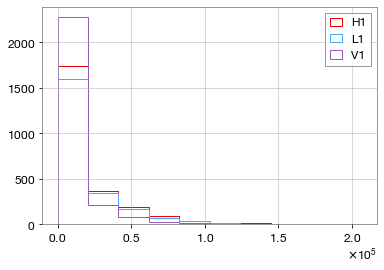

In [14]:
b=None
for ifo in ifos:
    h, b, _ = hist(
        segment_duration[ifo], bins=b, histtype="step", label=ifo, color=colors[ifo])
legend()

In [15]:
starts, ends = array(segments["V1"]).T
gaps = starts[1:] - ends[:-1]
min(gaps)

1

Text(0.5, 0, 'GPS seconds')

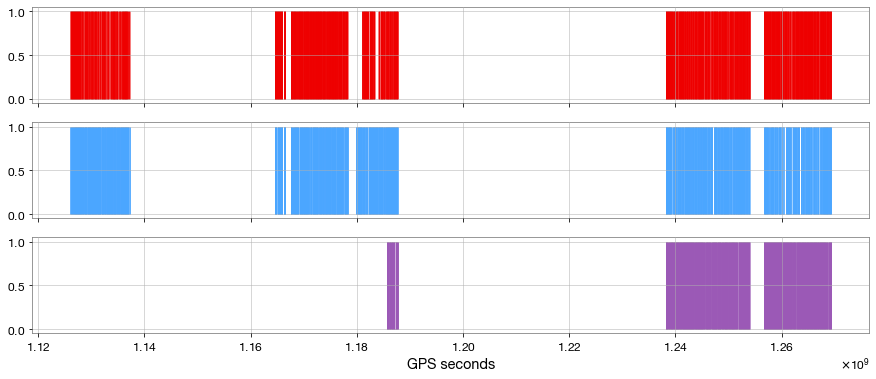

In [16]:
fig, axs = subplots(len(ifos), 1, sharex=True, figsize=(15,6))
axs = (ax for ax in axs)
linecolors={0:"k", 1:"r"}
for ifo in ifos:
    ax = next(axs)
    for i, (start, end) in enumerate(segments[ifo]):
#         ax.vlines([start, end], 0, 1, linestyles=[":", "-"], colors=linecolors[i%2], lw=4)
        ax.fill_between([start, end], 0, 1, color=colors[ifo], alpha=0.5)
        
# xlim(gps_start, gps_end)
xlabel("GPS seconds")

Text(0.5, 0, 'GPS seconds')

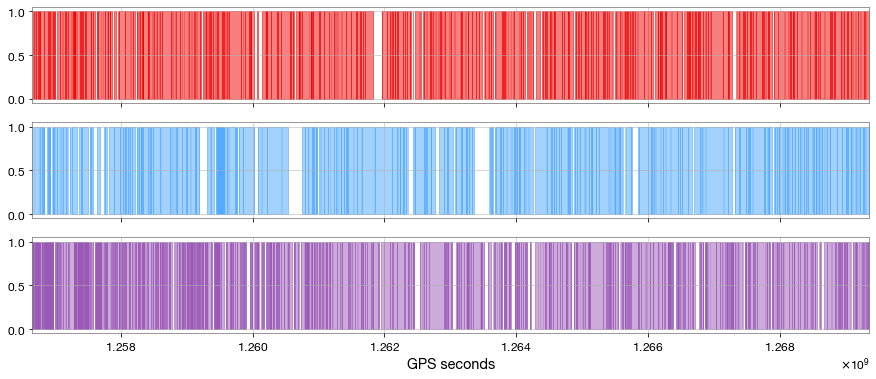

In [17]:
fig, axs = subplots(len(ifos), 1, sharex=True, figsize=(15,6))
axs = (ax for ax in axs)
linecolors={0:"k", 1:"r"}
for ifo in ifos:
    ax = next(axs)
    for i, (start, end) in enumerate(segments[ifo]):
#         ax.vlines([start, end], 0, 1, linestyles=[":", "-"], colors=linecolors[i%2], lw=4)
        ax.fill_between([start, end], 0, 1, color=colors[ifo], alpha=0.5)
        
xlim(gps_start, gps_end) #O3b
xlabel("GPS seconds")

# Explore number of chunks

In [58]:
longest_seg_idx = argmax(alens)
O3b[("H1", "L1", "V1")][longest_seg_idx], alens[longest_seg_idx]

(segment(1267651175, 1267736468), 85293)

In [52]:
alens = array([abs(s) for s in O3b[("H1", "L1", "V1")]])

In [54]:
min_analysis_segments = 1
min_analysis_length = 50
# min_analysis_length = 544
max_analysis_segments = 10
pad_data = 2
segment_length = 512
segment_end_pad = 16
segment_start_pad = 144

mask = alens<min_analysis_length
sum(mask) / len(alens)
sum(alens[mask]) / sum(alens) * 100

0.018375287350253622

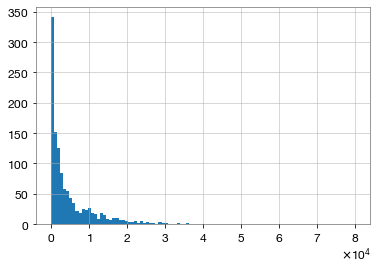

In [41]:
h, b, _ = hist(alens, bins=linspace(0,80000, 100));